## Support Vector Machine (SVM) Classifier

### Part 1

##### Importing necessary libraries and constant variables

In [1]:
import os

# Clone the repo into Colab's working directory
!git clone https://github.com/wip-0/ds207_final_project.git /content/ds207_final_project

# Add project root to Python path so 'src' is importable
import sys
sys.path.insert(0, '/content/ds207_final_project')

# Verify src exists
from pathlib import Path
src_path = Path('/content/ds207_final_project/src')
print(f"src exists: {src_path.exists()}")
print("src contents:")
for item in sorted(src_path.iterdir()):
    print(f"  {item.name}")

Cloning into '/content/ds207_final_project'...
remote: Enumerating objects: 1251, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 1251 (delta 58), reused 121 (delta 34), pack-reused 1071 (from 2)
Receiving objects: 100% (1251/1251), 202.57 MiB | 10.28 MiB/s, done.
Resolving deltas: 100% (571/571), done.
Updating files: 100% (252/252), done.
src exists: True
src contents:
  __init__.py
  analysis.py
  embed.py
  pipelines.py
  stats.py
  utils
  visualisations


In [2]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.9 MB/s eta 0:00:00


In [3]:
# custom imports
from src.utils.data_fetch import DataLoader
from src.visualisations.viz_model import plot_confusion_matrix

# sklearn libraries
from sklearn.svm import LinearSVC, SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

# other essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# various scoring metrics
from sklearn.metrics import (classification_report,
                             recall_score, precision_score,
                             f1_score, roc_auc_score,
                             average_precision_score,
                             ConfusionMatrixDisplay, confusion_matrix)

# for hyperparameter tuning
import optuna

SEED = 1234

##### Why LinearSVC?

We use `LinearSVC` instead of `SVC(kernel='rbf')` for scalability reasons.
With ~60k training rows and 125 features, RBF-SVM builds an n×n kernel matrix
which is computationally prohibitive. `LinearSVC` scales linearly with the number
of samples and is well-suited for high-dimensional one-hot encoded feature spaces.
We wrap it in `CalibratedClassifierCV` to enable `predict_proba()` for AUC-ROC scoring.

##### Functions to be used for model creation, evaluation and visualization

In [4]:
def fit_svm(Xtrain, ytrain, Xval,
            chosen_features_list=None,
            seed=SEED,
            c=1.0,
            max_iter=2000):
    """
    Fits a LinearSVC model (wrapped in CalibratedClassifierCV for probability
    estimates) on the selected features from the training dataset and evaluates
    it on both the training and validation datasets.

    Note: StandardScaler is NOT applied here since the data loaded via
    DataLoader().fetch_data(version='final_onehot') is already standardized
    by Vasileios's preprocessing pipeline (pipeline_standard__ columns).

    :param Xtrain: Training feature DataFrame.
    :param ytrain: Training target DataFrame (must contain 'readmitted' column).
    :param Xval: Validation feature DataFrame.
    :param chosen_features_list: List of feature names to use. Defaults to all features.
    :param seed: Random seed for reproducibility. Defaults to SEED.
    :param c: Regularization parameter (inverse of regularization strength).
    :param max_iter: Maximum number of iterations for LinearSVC.
    :return: Tuple of (fitted model, train predictions, validation predictions).
    """
    if chosen_features_list is None:
        chosen_features_list = Xtrain.columns.to_list()

    base_svm = LinearSVC(
        C=c,
        class_weight='balanced',
        max_iter=max_iter,
        random_state=seed
    )

    # CalibratedClassifierCV wraps LinearSVC to enable predict_proba()
    calibrated_svm = CalibratedClassifierCV(base_svm, cv=3)

    model = Pipeline(steps=[
        ('svm', calibrated_svm)   # no scaler — data already standardized
    ])

    model.fit(Xtrain[chosen_features_list], ytrain['readmitted'])

    y_pred_train = model.predict(Xtrain[chosen_features_list])
    y_pred_val   = model.predict(Xval[chosen_features_list])

    return model, y_pred_train, y_pred_val

In [5]:
## -> added to src.utils.model_eval.evaluation
def evaluate_predictions(true_values, predictions, print_class_report=True):
    """
    Evaluate classification predictions using recall, precision, F1-score,
    and optionally prints the classification report.

    :param true_values: DataFrame containing the actual class labels ('readmitted' column).
    :param predictions: Predicted labels.
    :param print_class_report: Whether to print the classification report. Defaults to True.
    :return: Tuple of (recall, precision, f1, classification_report string).
    """
    recall    = recall_score(y_true=true_values['readmitted'], y_pred=predictions)
    precision = precision_score(y_true=true_values['readmitted'], y_pred=predictions)
    f1        = f1_score(y_true=true_values['readmitted'], y_pred=predictions)
    cl_report = classification_report(
        y_true=true_values['readmitted'],
        y_pred=predictions,
        zero_division=0
    )
    if print_class_report:
        print(cl_report)
    return recall, precision, f1, cl_report

##### Loading the final processed data (one-hot encoded version)

In [6]:
df_Xtrain, df_Xval, df_Xtest, df_ytrain, df_yval, df_ytest = \
    DataLoader().fetch_data(version='final_onehot')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_test.csv 
Data imported succesfully from paths


### Part 2 - Draft Model (Numeric Features Only)

Choosing numeric features for a draft SVM model:

In [7]:
chosen_features = [
    'pipeline_standard__time_in_hospital',
    'pipeline_standard__num_lab_procedures',
    'pipeline_standard__num_procedures',
    'pipeline_standard__num_medications',
    'pipeline_standard__number_outpatient',
    'pipeline_standard__number_emergency',
    'pipeline_standard__number_inpatient',
    'pipeline_standard__number_diagnoses'
]

Dropping identifier columns and fitting draft model:

In [8]:
# Drop identifier columns
id_cols = [c for c in df_Xtrain.columns if 'encounter_id' in c or 'patient_nbr' in c]
X_train_svm = df_Xtrain.drop(columns=id_cols)
X_val_svm   = df_Xval.drop(columns=id_cols)
X_test_svm  = df_Xtest.drop(columns=id_cols)

# Fit draft model (numeric features only)
svm_draft, y_pred_tr, y_pred_vl = fit_svm(
    Xtrain=X_train_svm,
    ytrain=df_ytrain,
    Xval=X_val_svm,
    chosen_features_list=chosen_features,
    seed=SEED
)
svm_draft

Pipeline(steps=[('svm',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(class_weight='balanced',
                                                            max_iter=2000,
                                                            random_state=1234)))])

### Initial Classification Report: Training Set

              precision    recall  f1-score   support

           0       0.60      0.80      0.69     31515
           1       0.64      0.41      0.50     28090

    accuracy                           0.62     59605
   macro avg       0.62      0.60      0.60     59605
weighted avg       0.62      0.62      0.60     59605



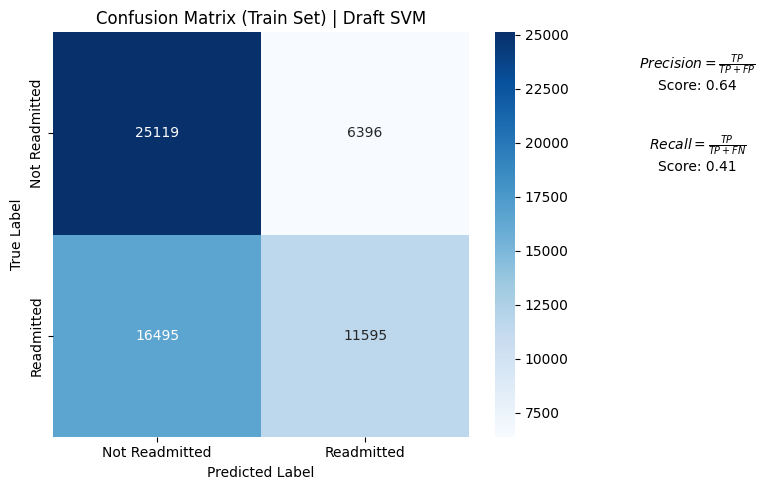

{'precision': 0.6444889111222277,
 'recall': 0.4127803488786045,
 'confusion_matrix': array([[25119,  6396],
        [16495, 11595]])}

In [9]:
recall_tr, precision_tr, f1_tr, cl_report_tr = \
    evaluate_predictions(true_values=df_ytrain,
                         predictions=y_pred_tr,
                         print_class_report=True)

plot_confusion_matrix(df_ytrain['readmitted'], y_pred_tr,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5),
                      title='Confusion Matrix (Train Set) | Draft SVM')

### Initial Classification Report: Validation Set

              precision    recall  f1-score   support

           0       0.61      0.81      0.69     10506
           1       0.66      0.41      0.51      9363

    accuracy                           0.62     19869
   macro avg       0.63      0.61      0.60     19869
weighted avg       0.63      0.62      0.61     19869



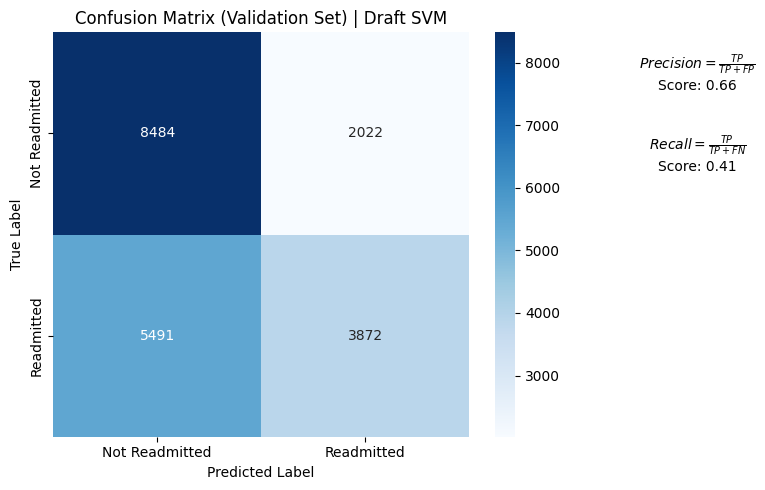

{'precision': 0.656939260264676,
 'recall': 0.4135426679483072,
 'confusion_matrix': array([[8484, 2022],
        [5491, 3872]])}

In [10]:
recall_vl, precision_vl, f1_vl, cl_report_vl = \
    evaluate_predictions(true_values=df_yval,
                         predictions=y_pred_vl,
                         print_class_report=True)

plot_confusion_matrix(df_yval['readmitted'], y_pred_vl,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5),
                      title='Confusion Matrix (Validation Set) | Draft SVM')

## Full Feature Model

---> Training set Evaluation

              precision    recall  f1-score   support

           0       0.62      0.77      0.68     31515
           1       0.64      0.47      0.54     28090

    accuracy                           0.63     59605
   macro avg       0.63      0.62      0.61     59605
weighted avg       0.63      0.63      0.62     59605



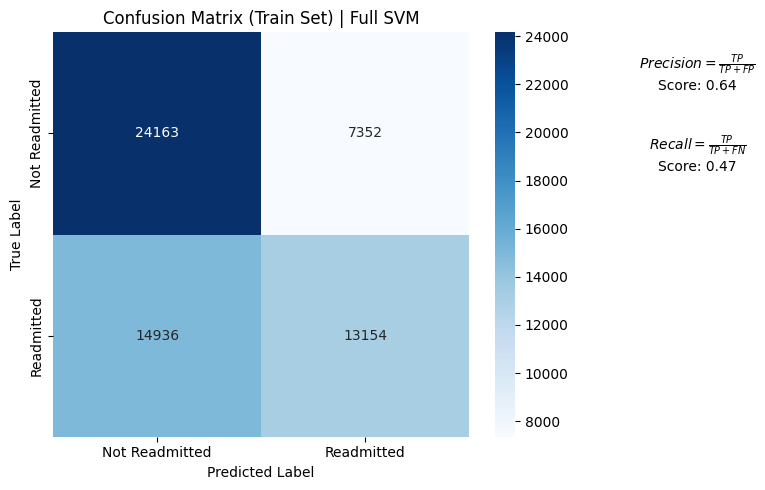

---> Validation set Evaluation

              precision    recall  f1-score   support

           0       0.62      0.77      0.69     10506
           1       0.64      0.46      0.54      9363

    accuracy                           0.63     19869
   macro avg       0.63      0.62      0.61     19869
weighted avg       0.63      0.63      0.62     19869



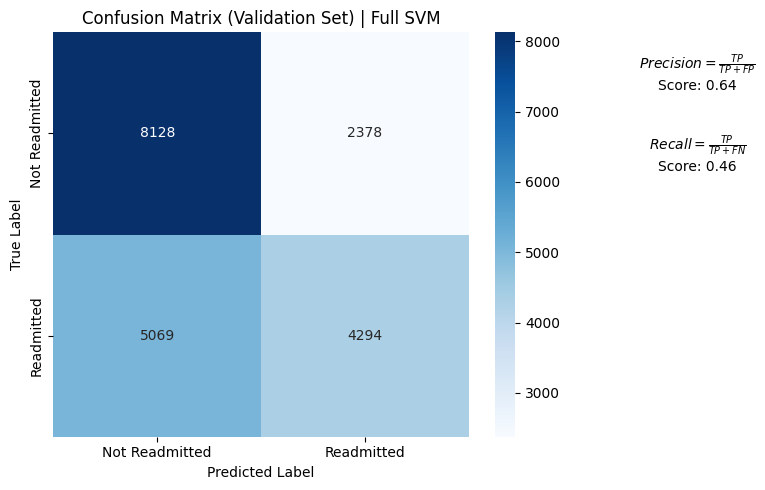

{'precision': 0.6435851318944844,
 'recall': 0.4586136921926733,
 'confusion_matrix': array([[8128, 2378],
        [5069, 4294]])}

In [11]:
svm_full, y_pred_tr, y_pred_vl = fit_svm(
    Xtrain=X_train_svm,
    ytrain=df_ytrain,
    Xval=X_val_svm,
    chosen_features_list=None,  # use all features
    seed=SEED
)

print('---> Training set Evaluation\n')
recall_tr, precision_tr, f1_tr, _ = \
    evaluate_predictions(true_values=df_ytrain,
                         predictions=y_pred_tr,
                         print_class_report=True)
plot_confusion_matrix(df_ytrain['readmitted'], y_pred_tr,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5), title='Confusion Matrix (Train Set) | Full SVM')

print('---> Validation set Evaluation\n')
recall_vl, precision_vl, f1_vl, _ = \
    evaluate_predictions(true_values=df_yval,
                         predictions=y_pred_vl,
                         print_class_report=True)
plot_confusion_matrix(df_yval['readmitted'], y_pred_vl,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5), title='Confusion Matrix (Validation Set) | Full SVM')

### Part 3 - Hyperparameter Tuning with Optuna

In [12]:
def objective(trial, X_train=X_train_svm, X_val=X_val_svm,
              ytrain=df_ytrain, yval=df_yval):

    svm_c = trial.suggest_float('svm_c', 1e-2, 1e2, log=True)

    model, _, _ = fit_svm(
        Xtrain=X_train, ytrain=ytrain, Xval=X_val,
        seed=SEED, c=svm_c
    )

    y_proba_val = model.predict_proba(X_val)[:, 1]
    return average_precision_score(yval['readmitted'], y_proba_val)

In [13]:
study = optuna.create_study(direction='maximize')
study.optimize(objective,
               #originally 30 trials, but I set to 5 for now
               n_trials=5,
               timeout=600,
               n_jobs=1)   # SVM does not benefit from parallel trials

[I 2026-07-31 02:26:29,967] A new study created in memory with name: no-name-54b107c0-d07a-4519-a076-7d8979d8e39f
[I 2026-07-31 02:26:57,526] Trial 0 finished with value: 0.6480434709961372 and parameters: {'svm_c': 43.33785539141457}. Best is trial 0 with value: 0.6480434709961372.
[I 2026-07-31 02:27:21,205] Trial 1 finished with value: 0.6480417618557581 and parameters: {'svm_c': 40.85025097614971}. Best is trial 0 with value: 0.6480434709961372.
[I 2026-07-31 02:27:43,566] Trial 2 finished with value: 0.6480414730714057 and parameters: {'svm_c': 17.35684749037792}. Best is trial 0 with value: 0.6480434709961372.
[I 2026-07-31 02:28:04,925] Trial 3 finished with value: 0.6480527395987716 and parameters: {'svm_c': 1.4169439618481579}. Best is trial 3 with value: 0.6480527395987716.
[I 2026-07-31 02:28:38,378] Trial 4 finished with value: 0.6480434581292397 and parameters: {'svm_c': 24.790374531112427}. Best is trial 3 with value: 0.6480527395987716.


In [14]:
print(study.best_trial)

FrozenTrial(number=3, state=<TrialState.COMPLETE: 1>, values=[0.6480527395987716], datetime_start=datetime.datetime(2026, 7, 31, 2, 27, 43, 570224), datetime_complete=datetime.datetime(2026, 7, 31, 2, 28, 4, 925601), params={'svm_c': 1.4169439618481579}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'svm_c': FloatDistribution(high=100.0, log=True, low=0.01, step=None)}, trial_id=3, value=None)


In [15]:
best_C = study.best_params['svm_c']
print(f'Best C value: {best_C}')

Best C value: 1.4169439618481579


### Part 4 - Re-train with Best C & Evaluate on Test Set

Validation set evaluation:
              precision    recall  f1-score   support

           0       0.62      0.77      0.69     10506
           1       0.64      0.46      0.54      9363

    accuracy                           0.63     19869
   macro avg       0.63      0.62      0.61     19869
weighted avg       0.63      0.63      0.62     19869



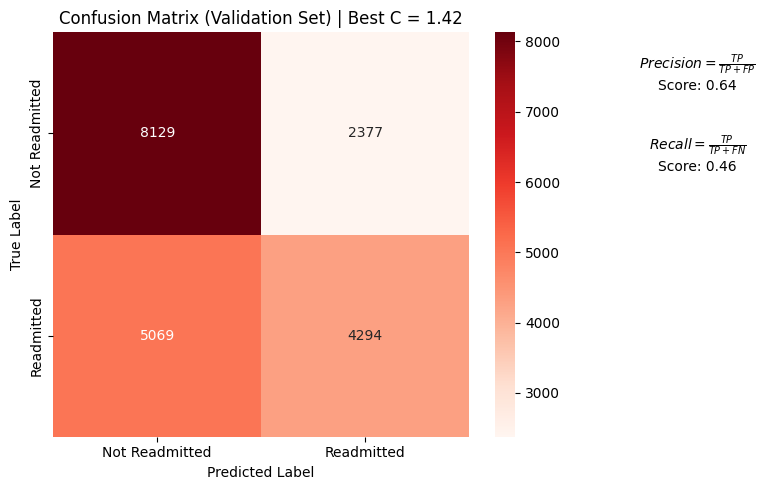

{'precision': 0.6436816069554789,
 'recall': 0.4586136921926733,
 'confusion_matrix': array([[8129, 2377],
        [5069, 4294]])}

In [16]:
best_svm, y_pred_tr, y_pred_vl = fit_svm(
    Xtrain=X_train_svm,
    ytrain=df_ytrain,
    Xval=X_val_svm,
    seed=SEED,
    c=best_C
)

print('Validation set evaluation:')
recall_vl, precision_vl, f1_vl, _ = \
    evaluate_predictions(true_values=df_yval,
                         predictions=y_pred_vl,
                         print_class_report=True)

plot_confusion_matrix(df_yval['readmitted'], y_pred_vl,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5), colour_map='Reds',
                      title='Confusion Matrix (Validation Set) | Best C = {:.2f}'.format(best_C))

In [17]:
from optuna.visualization import plot_slice
plot_slice(study)

#### Test Set (Unseen Data) Evaluation

Test set evaluation:
              precision    recall  f1-score   support

           0       0.62      0.77      0.69     10506
           1       0.64      0.46      0.54      9363

    accuracy                           0.63     19869
   macro avg       0.63      0.62      0.61     19869
weighted avg       0.63      0.63      0.62     19869



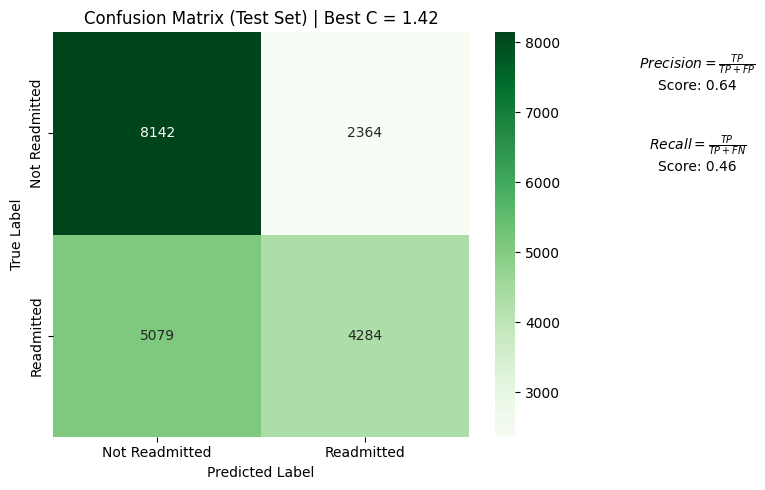

AUC-ROC  (Test Set): 0.6766
PR-AUC   (Test Set): 0.6516


In [21]:
y_pred_ts = best_svm.predict(X_test_svm)

print('Test set evaluation:')
recall_ts, precision_ts, f1_ts, _ = \
    evaluate_predictions(true_values=df_ytest,
                         predictions=y_pred_ts,
                         print_class_report=True)

plot_confusion_matrix(df_ytest['readmitted'], y_pred_ts,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5), colour_map='Greens',
                      title='Confusion Matrix (Test Set) | Best C = {:.2f}'.format(best_C))

# AUC-ROC and PR-AUC
y_proba_ts = best_svm.predict_proba(X_test_svm)[:, 1]  # or best_svm
auc_roc = roc_auc_score(df_ytest['readmitted'], y_proba_ts)
pr_auc  = average_precision_score(df_ytest['readmitted'], y_proba_ts)
print(f'AUC-ROC  (Test Set): {auc_roc:.4f}')
print(f'PR-AUC   (Test Set): {pr_auc:.4f}')